# Whitout balanced data 

In [1]:
import pandas as pd
import polars as pl


In [2]:
df = pd.read_csv("CVD_Dataset.csv")
df.head()

,Age,Gender,BMI,Ethnicity,SmokingStatus,AlcoholConsumption,SystolicBP,DiastolicBP,HeartRate,RespiratoryRate,...,AnkleArmIndex,CarotidIMT,CoronaryCalciumScore,MicroalbuminuriaLevel,Uric_Acid,Ferritin,Hemoglobin,WBC_Count,Platelet_Count,CVD_Label
0,57.5,Female,33.1,Other,Never,High,151.0,93.0,85.0,16.0,...,0.81,1.014,157.0,49.1,6.05,265.6,13.8,10.58,111.0,1
1,84.8,Female,29.9,Black,Never,Low,132.0,78.0,66.0,18.0,...,0.72,0.877,580.0,15.9,7.93,20.5,13.8,7.05,329.0,1
2,37.2,Female,19.3,Asian,Former,Low,142.0,91.0,75.0,16.0,...,1.10,0.613,18.0,5.5,5.29,27.3,16.5,9.19,131.0,0
3,49.1,Female,26.3,White,Never,Moderate,119.0,76.0,55.0,17.0,...,1.06,0.377,14.0,0.4,2.00,107.1,15.8,4.65,225.0,0
4,53.6,Male,28.2,Asian,Former,Moderate,100.0,60.0,67.0,18.0,...,1.11,0.759,2.0,10.7,7.00,71.5,18.0,3.58,205.0,0


In [3]:
df['CVD_Label'].value_counts()

CVD_Label
1    500
0    500
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1000 non-null   float64
 1   Gender                  1000 non-null   object 
 2   BMI                     1000 non-null   float64
 3   Ethnicity               1000 non-null   object 
 4   SmokingStatus           1000 non-null   object 
 5   AlcoholConsumption      1000 non-null   object 
 6   SystolicBP              1000 non-null   float64
 7   DiastolicBP             1000 non-null   float64
 8   HeartRate               1000 non-null   float64
 9   RespiratoryRate         1000 non-null   float64
 10  Cholesterol_Total       1000 non-null   float64
 11  LDL                     1000 non-null   float64
 12  HDL                     1000 non-null   float64
 13  Triglycerides           1000 non-null   float64
 14  BloodSugar              1000 non-null   f

## filing missing valuees

In [5]:
cat_col , num_col = df.select_dtypes('object').columns, df.select_dtypes(['int64', 'float64']).columns

df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])
df[num_col] = df[num_col].fillna(df[num_col].median())

In [6]:
df[cat_col]

,Gender,Ethnicity,SmokingStatus,AlcoholConsumption,PhysicalActivityLevel,ECG_Result
0,Female,Other,Never,High,Medium,Abnormal
1,Female,Black,Never,Low,Low,Abnormal
2,Female,Asian,Former,Low,High,Normal
3,Female,White,Never,Moderate,Medium,Normal
4,Male,Asian,Former,Moderate,Medium,Normal
...,...,...,...,...,...,...
995,Male,Black,Former,High,Low,Abnormal
996,Male,Hispanic,Never,Low,Medium,Normal
997,Female,White,Current,High,Low,Normal
998,Male,Asian,Current,Moderate,High,Normal


In [7]:
# df.isnull().sum()

In [8]:
for cat in cat_col:
    print("*"*50)
    print(df[cat].value_counts())
    print('\n\n')
 


**************************************************
Gender
Male      532
Female    468
Name: count, dtype: int64



**************************************************
Ethnicity
Asian       232
White       200
Hispanic    192
Other       188
Black       188
Name: count, dtype: int64



**************************************************
SmokingStatus
Never      427
Former     317
Current    256
Name: count, dtype: int64



**************************************************
AlcoholConsumption
Low         425
Moderate    390
High        185
Name: count, dtype: int64



**************************************************
PhysicalActivityLevel
Low       369
Medium    361
High      270
Name: count, dtype: int64



**************************************************
ECG_Result
Normal      615
Abnormal    385
Name: count, dtype: int64





In [9]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()

encode_df = df.copy()
for cat in cat_col:
    encode_df[cat] = encode.fit_transform(encode_df[cat])



In [10]:
encode_df[cat_col]

,Gender,Ethnicity,SmokingStatus,AlcoholConsumption,PhysicalActivityLevel,ECG_Result
0,0,3,2,0,2,0
1,0,1,2,1,1,0
2,0,0,1,1,0,1
3,0,4,2,2,2,1
4,1,0,1,2,2,1
...,...,...,...,...,...,...
995,1,1,1,0,1,0
996,1,2,2,1,2,1
997,0,4,0,0,1,1
998,1,0,0,2,0,1


In [11]:
X, y = encode_df.drop(['CVD_Label'], axis=1), encode_df['CVD_Label']

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost.sklearn import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

In [13]:
models = {
    "Logistic Regression": LogisticRegression(),
         

    "dt":DecisionTreeClassifier(),

    'gnb':GaussianNB( ),

    "SVM": SVC(
        kernel="rbf",
        C=0.5,                 # Lower C = more regularization (prevents overfitting)
        gamma="scale",         # Uses 1 / (n_features * X.var())
        class_weight="balanced",
        probability=True,      # Keep True only if you need ROC-AUC or soft voting
        cache_size=500,        # Uses more RAM to speed up training
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
         
    ),
    
    
    "KNN": KNeighborsClassifier( ),


    # "grdi":GradientBoostingClassifier(learning_rate=0.001, n_estimators=100, min_samples_split=0.2),


    "XGBoost": XGBClassifier(
        n_estimators=100 
    )
}

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [15]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9114
False Positive Rate (FPR): 0.0845

Accuracy  : 0.9133
Precision : 0.9231
Recall    : 0.9114
F1-Score  : 0.9172
ROC-AUC   : 0.9144

Confusion Matrix:
[[130  12]
 [ 14 144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       142
           1       0.92      0.91      0.92       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7785
False Positive Rate (FPR): 0.1901

Accuracy  : 0.7933
Precision : 0.8200
Recall    : 0.7785
F1-Score  : 0.7987
ROC-AUC   : 0.7942

Confusion Matrix:
[[115  27]
 [ 35 

In [16]:
X = encode_df.drop(['CVD_Label'], axis=1).to_numpy()
y =  df['CVD_Label'].to_numpy()

In [17]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "results_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Validation Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.3349, Val Loss: 0.2788
Epoch 20, Train Loss: 0.2881, Val Loss: 0.2779
Early stopping at epoch: 29

Threshold Tuning:
Threshold 0.30: Accuracy 0.8933
Threshold 0.35: Accuracy 0.9067
Threshold 0.40: Accuracy 0.9067
Threshold 0.45: Accuracy 0.9067
Threshold 0.50: Accuracy 0.9067
Threshold 0.55: Accuracy 0.9067
Threshold 0.60: Accuracy 0.9067
Threshold 0.65: Accuracy 0.8933
Threshold 0.70: Accuracy 0.8867
Threshold 0.75: Accuracy 0.8733

Best Threshold: 0.35

Final Results:
Accuracy: 0.9066666666666666

Confusion Matrix:
[[63  8]
 [ 6 73]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90        71
         1.0       0.90      0.92      0.91        79

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150

True Positive Rate (TPR):  0.9241
False Positive Rate (FPR): 0.1127

ROC-AUC Score:

In [18]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "results_0_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Test Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.1596, Val Loss: 0.4035
Early stopping at epoch: 19

Threshold Tuning:
Threshold 0.30: Accuracy 0.8533
Threshold 0.35: Accuracy 0.8600
Threshold 0.40: Accuracy 0.8667
Threshold 0.45: Accuracy 0.8800
Threshold 0.50: Accuracy 0.8667
Threshold 0.55: Accuracy 0.8600
Threshold 0.60: Accuracy 0.8667
Threshold 0.65: Accuracy 0.8600
Threshold 0.70: Accuracy 0.8600
Threshold 0.75: Accuracy 0.8467

Best Threshold: 0.45

Final Results:
Accuracy: 0.88

Confusion Matrix:
[[62  9]
 [ 9 70]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87        71
         1.0       0.89      0.89      0.89        79

    accuracy                           0.88       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150


ROC-AUC Score:
0.9028347298983775
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.1268
Precision: 0.8861
Recall:    0.8861
F1-Sc

# Balanced data

In [19]:
X = encode_df.drop('CVD_Label',axis=1)
y = encode_df['CVD_Label']

## sdfc


In [20]:
from sklearn.feature_selection import SelectKBest, f_classif

sdfs = SelectKBest(score_func=f_classif, k=10)
X_sdfs = sdfs.fit_transform(X, y)

selected_sdfs = X.columns[sdfs.get_support()]
print("SDFS Selected:", selected_sdfs)

SDFS Selected: Index(['HDL', 'HbA1c', 'ArteryBlockageScore', 'PlaqueVolume',
       'VascularStiffness', 'HomocysteineLevel', 'ApolipoproteinB',
       'ApolipoproteinA1', 'AnkleArmIndex', 'CarotidIMT'],
      dtype='object')


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X_sdfs, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [22]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8987
False Positive Rate (FPR): 0.0845

Accuracy  : 0.9067
Precision : 0.9221
Recall    : 0.8987
F1-Score  : 0.9103
ROC-AUC   : 0.9048

Confusion Matrix:
[[130  12]
 [ 16 142]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       142
           1       0.92      0.90      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7785
False Positive Rate (FPR): 0.1972

Accuracy  : 0.7900
Precision : 0.8146
Recall    : 0.7785
F1-Score  : 0.7961
ROC-AUC   : 0.7906

Confusion Matrix:
[[114  28]
 [ 35 

In [23]:
X = encode_df.drop(['CVD_Label'], axis=1).to_numpy()
y =  df['CVD_Label'].to_numpy()

Epoch 10, Train Loss: 0.1270, Val Loss: 0.3179
Early stopping at epoch: 16

Threshold Tuning:
Threshold 0.30: Accuracy 0.8867
Threshold 0.35: Accuracy 0.8933
Threshold 0.40: Accuracy 0.9000
Threshold 0.45: Accuracy 0.8933
Threshold 0.50: Accuracy 0.8933
Threshold 0.55: Accuracy 0.8800
Threshold 0.60: Accuracy 0.8800
Threshold 0.65: Accuracy 0.8733
Threshold 0.70: Accuracy 0.8733
Threshold 0.75: Accuracy 0.8667

Best Threshold: 0.40

Final Results:
Accuracy: 0.9

Confusion Matrix:
[[63  8]
 [ 7 72]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.89        71
         1.0       0.90      0.91      0.91        79

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


ROC-AUC Score:
0.9012301658049563
True Positive Rate (TPR):  0.9114
False Positive Rate (FPR): 0.1127
Precision: 0.9000
Recall:    0.9114
F1-Sco

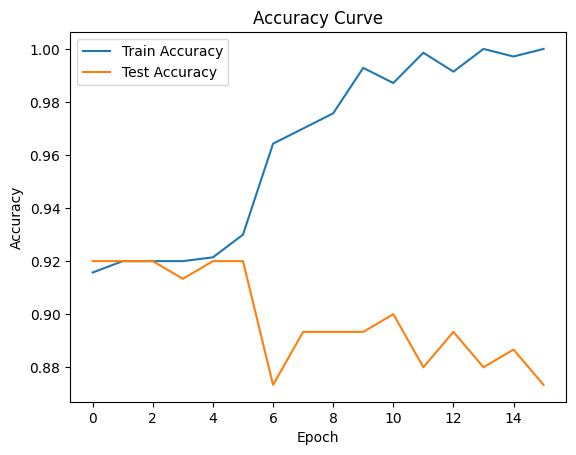

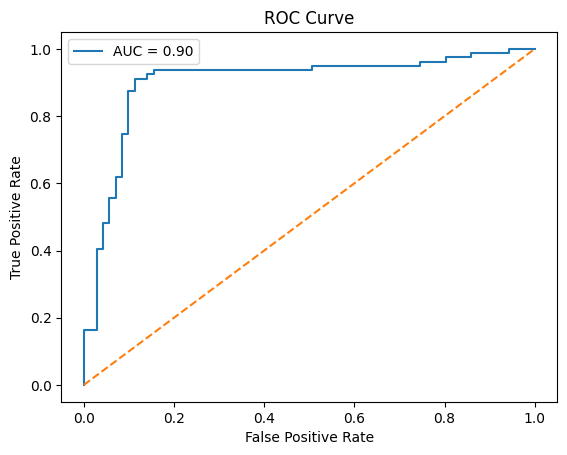

In [24]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "SDFS_results_0_cvd"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

## cfs

In [25]:
X = encode_df.drop('CVD_Label', axis=1)
y = encode_df['CVD_Label']

In [26]:
import numpy as np

corr = X.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

drop_cols = [col for col in upper.columns if any(upper[col] > 0.85)]

X_cfs = X.drop(columns=drop_cols)

print("Dropped:", drop_cols)
print("CFS Remaining:", X_cfs.columns)

Dropped: ['DiastolicBP', 'PulsePressure']
CFS Remaining: Index(['Age', 'Gender', 'BMI', 'Ethnicity', 'SmokingStatus',
       'AlcoholConsumption', 'SystolicBP', 'HeartRate', 'RespiratoryRate',
       'Cholesterol_Total', 'LDL', 'HDL', 'Triglycerides', 'BloodSugar',
       'HbA1c', 'PhysicalActivityLevel', 'DietScore', 'SleepHours',
       'StressLevel', 'DiabetesHistory', 'HypertensionHistory',
       'FamilyHistory_CVD', 'ECG_Result', 'ArteryBlockageScore',
       'InflammationMarker_CRP', 'OxygenSaturation', 'MedicationAdherence',
       'PlaqueVolume', 'CardiacOutput', 'VascularStiffness', 'TroponinLevel',
       'BNP_Level', 'HomocysteineLevel', 'FibrinogenLevel', 'Lipoprotein_a',
       'ApolipoproteinB', 'ApolipoproteinA1', 'GlomerularFilterRate',
       'AnkleArmIndex', 'CarotidIMT', 'CoronaryCalciumScore',
       'MicroalbuminuriaLevel', 'Uric_Acid', 'Ferritin', 'Hemoglobin',
       'WBC_Count', 'Platelet_Count'],
      dtype='object')


In [27]:
X_cfs.head(
)

,Age,Gender,BMI,Ethnicity,SmokingStatus,AlcoholConsumption,SystolicBP,HeartRate,RespiratoryRate,Cholesterol_Total,...,GlomerularFilterRate,AnkleArmIndex,CarotidIMT,CoronaryCalciumScore,MicroalbuminuriaLevel,Uric_Acid,Ferritin,Hemoglobin,WBC_Count,Platelet_Count
0,57.5,0,33.1,3,2,0,151.0,85.0,16.0,248.9,...,87.2,0.81,1.014,157.0,49.1,6.05,265.6,13.8,10.58,111.0
1,84.8,0,29.9,1,2,1,132.0,66.0,18.0,228.9,...,66.7,0.72,0.877,580.0,15.9,7.93,20.5,13.8,7.05,329.0
2,37.2,0,19.3,0,1,1,142.0,75.0,16.0,206.2,...,110.4,1.10,0.613,18.0,5.5,5.29,27.3,16.5,9.19,131.0
3,49.1,0,26.3,4,2,2,119.0,55.0,17.0,190.7,...,48.9,1.06,0.377,14.0,0.4,2.00,107.1,15.8,4.65,225.0
4,53.6,1,28.2,0,1,2,100.0,67.0,18.0,172.1,...,104.0,1.11,0.759,2.0,10.7,7.00,71.5,18.0,3.58,205.0


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X_cfs, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [29]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9114
False Positive Rate (FPR): 0.0845

Accuracy  : 0.9133
Precision : 0.9231
Recall    : 0.9114
F1-Score  : 0.9172
ROC-AUC   : 0.9145

Confusion Matrix:
[[130  12]
 [ 14 144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       142
           1       0.92      0.91      0.92       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8038
False Positive Rate (FPR): 0.1831

Accuracy  : 0.8100
Precision : 0.8301
Recall    : 0.8038
F1-Score  : 0.8167
ROC-AUC   : 0.8103

Confusion Matrix:
[[116  26]
 [ 31 

## bfe

In [30]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

bfe = RFE(model, n_features_to_select=30)
bfe.fit(X, y)

selected_bfe = X.columns[bfe.support_]
print("BFE Selected:", selected_bfe)

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://sciki

BFE Selected: Index(['Age', 'Gender', 'BMI', 'SmokingStatus', 'AlcoholConsumption',
       'SystolicBP', 'HeartRate', 'RespiratoryRate', 'HbA1c',
       'PhysicalActivityLevel', 'DietScore', 'SleepHours', 'DiabetesHistory',
       'HypertensionHistory', 'FamilyHistory_CVD', 'ECG_Result',
       'ArteryBlockageScore', 'InflammationMarker_CRP', 'OxygenSaturation',
       'MedicationAdherence', 'CardiacOutput', 'TroponinLevel',
       'HomocysteineLevel', 'ApolipoproteinA1', 'GlomerularFilterRate',
       'AnkleArmIndex', 'CarotidIMT', 'MicroalbuminuriaLevel', 'Uric_Acid',
       'WBC_Count'],
      dtype='object')


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
selected_bfe.values


array(['Age', 'Gender', 'BMI', 'SmokingStatus', 'AlcoholConsumption',
       'SystolicBP', 'HeartRate', 'RespiratoryRate', 'HbA1c',
       'PhysicalActivityLevel', 'DietScore', 'SleepHours',
       'DiabetesHistory', 'HypertensionHistory', 'FamilyHistory_CVD',
       'ECG_Result', 'ArteryBlockageScore', 'InflammationMarker_CRP',
       'OxygenSaturation', 'MedicationAdherence', 'CardiacOutput',
       'TroponinLevel', 'HomocysteineLevel', 'ApolipoproteinA1',
       'GlomerularFilterRate', 'AnkleArmIndex', 'CarotidIMT',
       'MicroalbuminuriaLevel', 'Uric_Acid', 'WBC_Count'], dtype=object)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_bfe], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [33]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8987
False Positive Rate (FPR): 0.0845

Accuracy  : 0.9067
Precision : 0.9221
Recall    : 0.8987
F1-Score  : 0.9103
ROC-AUC   : 0.9122

Confusion Matrix:
[[130  12]
 [ 16 142]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       142
           1       0.92      0.90      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7215
False Positive Rate (FPR): 0.2113

Accuracy  : 0.7533
Precision : 0.7917
Recall    : 0.7215
F1-Score  : 0.7550
ROC-AUC   : 0.7551

Confusion Matrix:
[[112  30]
 [ 44 

pso

In [34]:
# from pyswarm import pso
# from sklearn.model_selection import cross_val_score
# from sklearn.ensemble import RandomForestClassifier

# def fitness_function(mask):
#     mask = mask > 0.5
#     if sum(mask) == 0:
#         return 1
    
#     X_selected = X.iloc[:, mask]
#     model = RandomForestClassifier()
    
#     score = cross_val_score(model, X_selected, y, cv=3).mean()
    
#     return 1 - score  # minimize

# lb = [0]*X.shape[1]
# ub = [1]*X.shape[1]

# best_mask, _ = pso(fitness_function, lb, ub)

# selected_pso = X.columns[best_mask > 0.5]
# print("PSO Selected:", selected_pso)

## ga

In [35]:
from sklearn_genetic import GAFeatureSelectionCV
from sklearn.ensemble import RandomForestClassifier

ga = GAFeatureSelectionCV(
    estimator=RandomForestClassifier(),
    cv=3,
    scoring="accuracy",
    population_size=10,
    generations=10,
    n_jobs=-1
)

ga.fit(X, y)

selected_ga = X.columns[ga.support_]
print("GA Selected:", selected_ga)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	10    	0.909699	0.00405321 	0.914001   	0.900991   
1  	20    	0.912801	0.00132635 	0.915002   	0.910003   
2  	20    	0.9123  	0.00118782 	0.914001   	0.910998   
3  	20    	0.911899	0.00281078 	0.914001   	0.903994   
4  	20    	0.914301	0.000640953	0.915002   	0.913      
5  	20    	0.913302	0.002282   	0.916003   	0.909002   
6  	20    	0.914101	0.00164101 	0.916003   	0.91       
7  	20    	0.913301	0.00184735 	0.916003   	0.909997   
8  	20    	0.914002	0.00161314 	0.916003   	0.911001   
9  	20    	0.914301	0.00161693 	0.916003   	0.909997   
10 	20    	0.913301	0.0025728  	0.915002   	0.906997   
GA Selected: Index(['Gender', 'Ethnicity', 'AlcoholConsumption', 'DiastolicBP',
       'RespiratoryRate', 'Cholesterol_Total', 'LDL', 'Triglycerides', 'HbA1c',
       'StressLevel', 'FamilyHistory_CVD', 'ECG_Result', 'PlaqueVolume',
       'CardiacOutput', 'PulsePressure', 'BNP_Level', 'FibrinogenLevel',
       'Lipoprotein_a'

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_ga], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [37]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9114
False Positive Rate (FPR): 0.0845

Accuracy  : 0.9133
Precision : 0.9231
Recall    : 0.9114
F1-Score  : 0.9172
ROC-AUC   : 0.9178

Confusion Matrix:
[[130  12]
 [ 14 144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       142
           1       0.92      0.91      0.92       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8608
False Positive Rate (FPR): 0.1761

Accuracy  : 0.8433
Precision : 0.8447
Recall    : 0.8608
F1-Score  : 0.8527
ROC-AUC   : 0.8424

Confusion Matrix:
[[117  25]
 [ 22 

##  ssa

In [38]:
import random

def salp_swarm(X, y, iterations=10):
    best_features = list(X.columns)
    best_score = 0
    
    for _ in range(iterations):
        selected = random.sample(list(X.columns), k=30)
        
        model = RandomForestClassifier()
        score = cross_val_score(model, X[selected], y, cv=3).mean()
        
        if score > best_score:
            best_score = score
            best_features = selected
            
    return best_features

selected_ssa = salp_swarm(X, y)
print("SSA Selected:", selected_ssa)

SSA Selected: ['VascularStiffness', 'CarotidIMT', 'ApolipoproteinB', 'AlcoholConsumption', 'HeartRate', 'HypertensionHistory', 'Triglycerides', 'SmokingStatus', 'MedicationAdherence', 'RespiratoryRate', 'AnkleArmIndex', 'Platelet_Count', 'DiastolicBP', 'Lipoprotein_a', 'Ethnicity', 'HDL', 'GlomerularFilterRate', 'Gender', 'Hemoglobin', 'PlaqueVolume', 'Age', 'HbA1c', 'ApolipoproteinA1', 'PulsePressure', 'BloodSugar', 'DiabetesHistory', 'ECG_Result', 'WBC_Count', 'LDL', 'MicroalbuminuriaLevel']


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_ssa], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [40]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8987
False Positive Rate (FPR): 0.0845

Accuracy  : 0.9067
Precision : 0.9221
Recall    : 0.8987
F1-Score  : 0.9103
ROC-AUC   : 0.9097

Confusion Matrix:
[[130  12]
 [ 16 142]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       142
           1       0.92      0.90      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7848
False Positive Rate (FPR): 0.1901

Accuracy  : 0.7967
Precision : 0.8212
Recall    : 0.7848
F1-Score  : 0.8026
ROC-AUC   : 0.7973

Confusion Matrix:
[[115  27]
 [ 34 

## rsfs

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

importance = rf.feature_importances_

selected_rsfs = X.columns[importance > np.mean(importance)]
print("RSFS Selected:", selected_rsfs)

RSFS Selected: Index(['LDL', 'HDL', 'HbA1c', 'DietScore', 'StressLevel',
       'ArteryBlockageScore', 'OxygenSaturation', 'PlaqueVolume',
       'VascularStiffness', 'HomocysteineLevel', 'FibrinogenLevel',
       'ApolipoproteinB', 'ApolipoproteinA1', 'AnkleArmIndex', 'CarotidIMT',
       'CoronaryCalciumScore', 'MicroalbuminuriaLevel'],
      dtype='object')


In [42]:
chart = pd.DataFrame({
    'Feature': X.columns,
    'importance': importance
})

# Keep features above mean importance
selected_features = chart[chart['importance'] > chart['importance'].mean()]

print(selected_features)

                  Feature  importance
11                    LDL    0.022340
12                    HDL    0.033300
15                  HbA1c    0.036919
17              DietScore    0.020569
19            StressLevel    0.020461
24    ArteryBlockageScore    0.053584
26       OxygenSaturation    0.021954
28           PlaqueVolume    0.088974
31      VascularStiffness    0.040252
34      HomocysteineLevel    0.038481
35        FibrinogenLevel    0.028737
37        ApolipoproteinB    0.024713
38       ApolipoproteinA1    0.044933
40          AnkleArmIndex    0.040324
41             CarotidIMT    0.075419
42   CoronaryCalciumScore    0.065724
43  MicroalbuminuriaLevel    0.041796


In [43]:
# import plotly.express as px

# for col in selected_rsfs:
#     fig = px.histogram(
#         df,
#         x=col,                 # use current feature
#         color="CVD_Label",        #"CVD_Label"
#         nbins=20,
#         barmode="overlay",     # overlay disease vs no disease
#         opacity=0.6,
#         title=f"{col} Distribution: Disease vs No Disease"
#     )

#     fig.update_layout(
#         xaxis_title=col,
#         yaxis_title="Count",
#         bargap=0.1
#     )

#     fig.write_image(f"rfsc_cvd_images/{col}.png", width=800, height=800)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_rsfs], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [45]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9051
False Positive Rate (FPR): 0.0845

Accuracy  : 0.9100
Precision : 0.9226
Recall    : 0.9051
F1-Score  : 0.9137
ROC-AUC   : 0.9022

Confusion Matrix:
[[130  12]
 [ 15 143]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       142
           1       0.92      0.91      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8101
False Positive Rate (FPR): 0.1901

Accuracy  : 0.8100
Precision : 0.8258
Recall    : 0.8101
F1-Score  : 0.8179
ROC-AUC   : 0.8100

Confusion Matrix:
[[115  27]
 [ 30 

In [46]:
import matplotlib.pyplot as plt
import os

# Create results folder
results_dir = "results_roc_CVD"
os.makedirs(results_dir, exist_ok=True)

# Loop through each model to create individual plots
for model_name, metrics in results.items():
    # 1. Create a NEW figure for every model
    plt.figure(figsize=(8, 6))
    
    # 2. Plot the specific model line
    plt.plot(
        metrics['fpr'], 
        metrics['tpr'], 
        color='darkorange',
        lw=2, 
        label=f"{model_name} (AUC = {metrics['AUC']:.4f})"
    )

    # 3. Add the baseline "Random Guess" line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.50)')

    # 4. Formatting (Individual for this model)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # 5. Save using the model name in the filename
    # Sanitize model name to avoid filename issues (replace spaces with underscores)
    clean_name = model_name.replace(" ", "_")
    save_path = os.path.join(results_dir, f"roc_{clean_name}.png")
    plt.savefig(save_path)
    
    # 6. Close the plot to free up memory before the next loop
    # plt.show() 
    plt.close()

print(f"All individual charts have been saved in: {results_dir}")

All individual charts have been saved in: results_roc_CVD


## apdfs

In [47]:
import numpy as np

def apdfs(X, y, iterations=20):
    best_features = None
    best_score = 0
    
    for _ in range(iterations):
        prob = np.random.rand(X.shape[1])
        mask = prob > 0.5
        
        if sum(mask) == 0:
            continue
        
        selected = X.columns[mask]
        
        model = RandomForestClassifier()
        score = cross_val_score(model, X[selected], y, cv=3).mean()
        
        if score > best_score:
            best_score = score
            best_features = selected
            
    return best_features

selected_apdfs = apdfs(X, y)
print("APDFS Selected:", selected_apdfs)

APDFS Selected: Index(['Age', 'SmokingStatus', 'DiastolicBP', 'RespiratoryRate',
       'Cholesterol_Total', 'LDL', 'Triglycerides', 'HbA1c', 'SleepHours',
       'StressLevel', 'DiabetesHistory', 'FamilyHistory_CVD', 'ECG_Result',
       'InflammationMarker_CRP', 'MedicationAdherence', 'PulsePressure',
       'VascularStiffness', 'FibrinogenLevel', 'ApolipoproteinA1',
       'AnkleArmIndex', 'CarotidIMT', 'MicroalbuminuriaLevel', 'Hemoglobin',
       'Platelet_Count'],
      dtype='object')


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_apdfs], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [49]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.0915

Accuracy  : 0.8967
Precision : 0.9150
Recall    : 0.8861
F1-Score  : 0.9003
ROC-AUC   : 0.9107

Confusion Matrix:
[[129  13]
 [ 18 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       142
           1       0.92      0.89      0.90       158

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7785
False Positive Rate (FPR): 0.1972

Accuracy  : 0.7900
Precision : 0.8146
Recall    : 0.7785
F1-Score  : 0.7961
ROC-AUC   : 0.7906

Confusion Matrix:
[[114  28]
 [ 35 

In [56]:
X = encode_df[selected_apdfs].to_numpy()
y =  df['CVD_Label'].to_numpy()

Epoch 10, Train Loss: 0.2329, Val Loss: 0.3505
Early stopping at epoch: 19

Threshold Tuning:
Threshold 0.30: Accuracy 0.8800
Threshold 0.35: Accuracy 0.8800
Threshold 0.40: Accuracy 0.8733
Threshold 0.45: Accuracy 0.8733
Threshold 0.50: Accuracy 0.8733
Threshold 0.55: Accuracy 0.8667
Threshold 0.60: Accuracy 0.8667
Threshold 0.65: Accuracy 0.8667
Threshold 0.70: Accuracy 0.8667
Threshold 0.75: Accuracy 0.8600

Best Threshold: 0.30

Final Results:
Accuracy: 0.88

Confusion Matrix:
[[60 11]
 [ 7 72]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.85      0.87        71
         1.0       0.87      0.91      0.89        79

    accuracy                           0.88       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150


ROC-AUC Score:
0.9024781600998396
True Positive Rate (TPR):  0.9114
False Positive Rate (FPR): 0.1549
Precision: 0.8675
Recall:    0.9114
F1-Sc

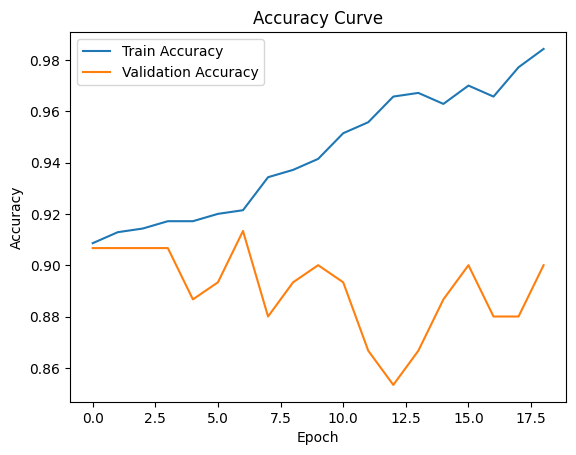

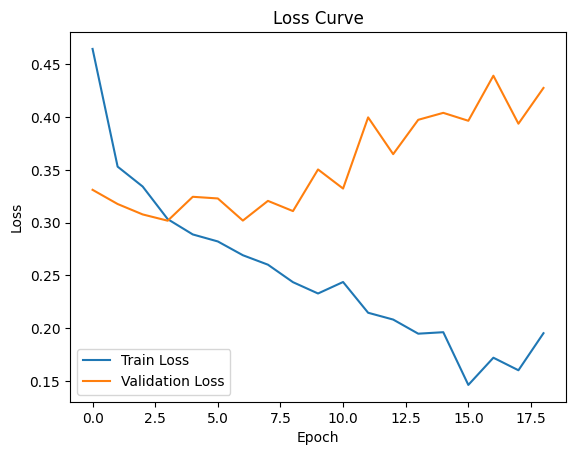

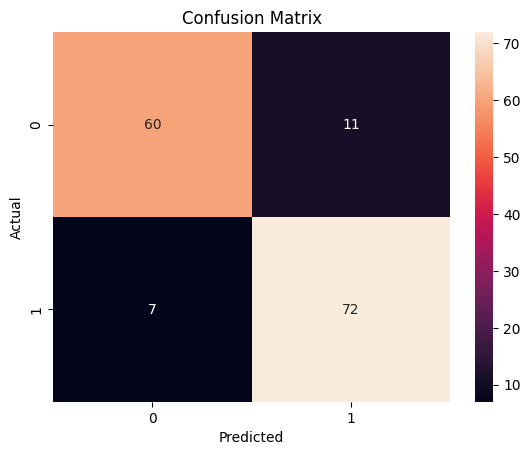

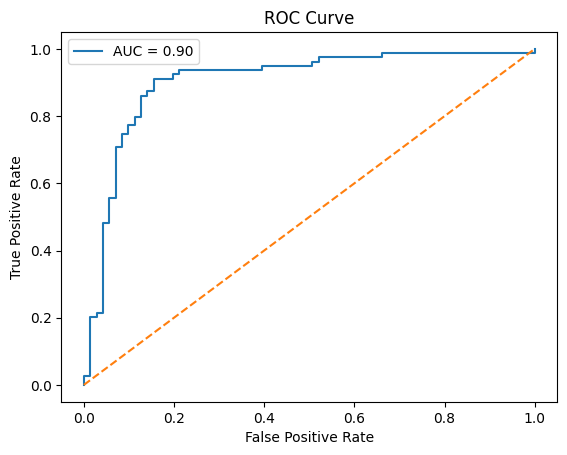

In [58]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "APDFS_results_0_CVD"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

## deep leaning

In [50]:
X = encode_df[selected_rsfs].to_numpy()
y =  df['CVD_Label'].to_numpy()

Epoch 10, Train Loss: 0.3682, Val Loss: 0.2924
Epoch 20, Train Loss: 0.3339, Val Loss: 0.2942
Epoch 30, Train Loss: 0.3176, Val Loss: 0.2983
Early stopping at epoch: 33

Threshold Tuning:
Threshold 0.30: Accuracy 0.9000
Threshold 0.35: Accuracy 0.9000
Threshold 0.40: Accuracy 0.9067
Threshold 0.45: Accuracy 0.9067
Threshold 0.50: Accuracy 0.9000
Threshold 0.55: Accuracy 0.9000
Threshold 0.60: Accuracy 0.9000
Threshold 0.65: Accuracy 0.8933
Threshold 0.70: Accuracy 0.8867
Threshold 0.75: Accuracy 0.8733

Best Threshold: 0.40

Final Results:
Accuracy: 0.9066666666666666

Confusion Matrix:
[[63  8]
 [ 6 73]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90        71
         1.0       0.90      0.92      0.91        79

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150

True Positive Rate (TPR):  0.9241
Fa

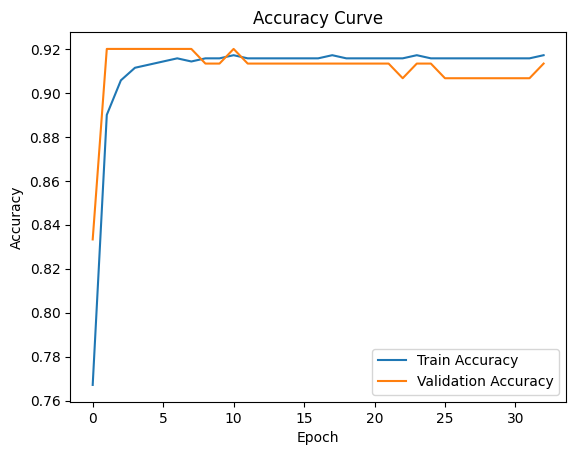

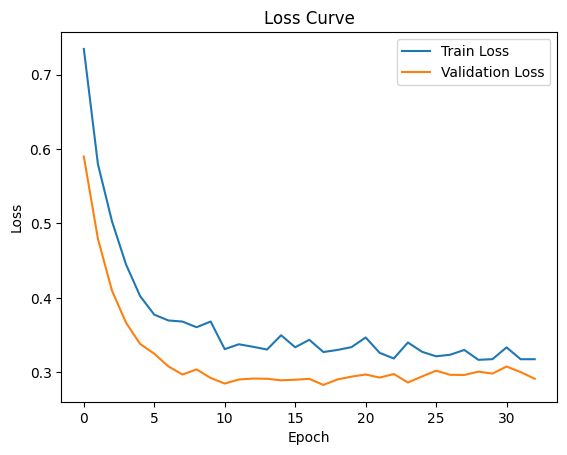

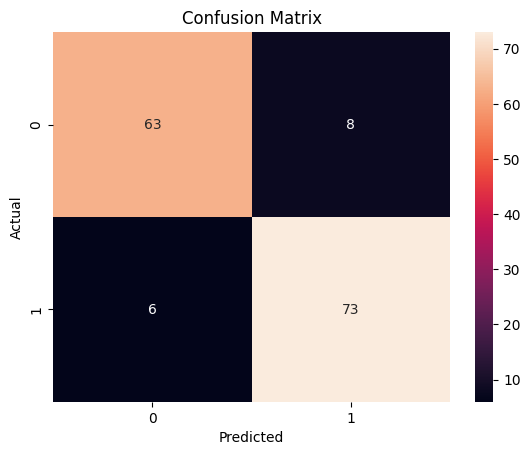

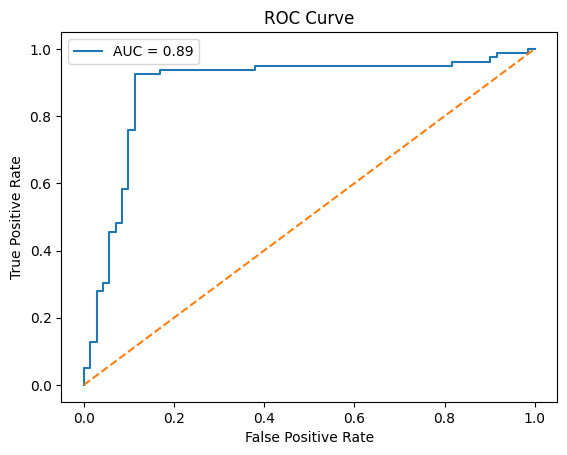

In [62]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model

model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

Epoch 10, Train Loss: 0.2297, Val Loss: 0.3082
Early stopping at epoch: 16

Threshold Tuning:
Threshold 0.30: Accuracy 0.8600
Threshold 0.35: Accuracy 0.8600
Threshold 0.40: Accuracy 0.8667
Threshold 0.45: Accuracy 0.8667
Threshold 0.50: Accuracy 0.8600
Threshold 0.55: Accuracy 0.8667
Threshold 0.60: Accuracy 0.8667
Threshold 0.65: Accuracy 0.8800
Threshold 0.70: Accuracy 0.8800
Threshold 0.75: Accuracy 0.8800

Best Threshold: 0.65

Final Results:
Accuracy: 0.88

Confusion Matrix:
[[62  9]
 [ 9 70]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87        71
         1.0       0.89      0.89      0.89        79

    accuracy                           0.88       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150


ROC-AUC Score:
0.8916027812444286
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.1268
Precision: 0.8861
Recall:    0.8861
F1-Sc

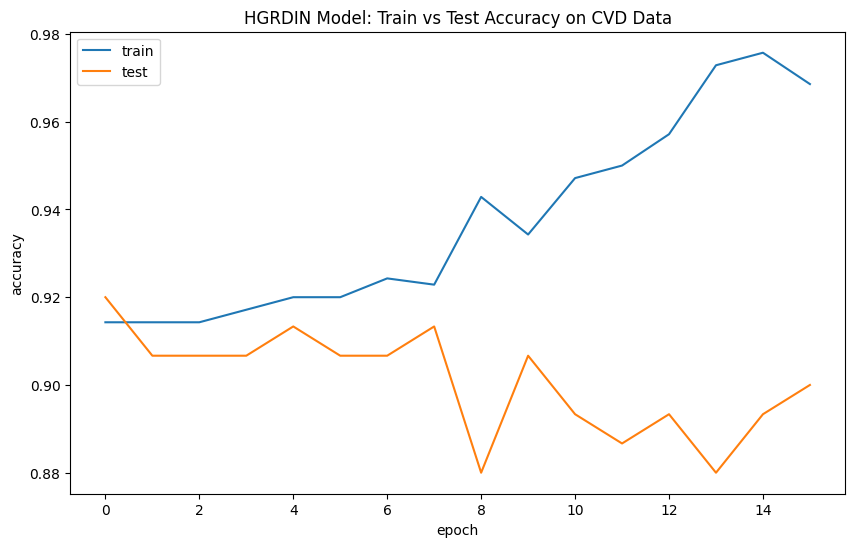

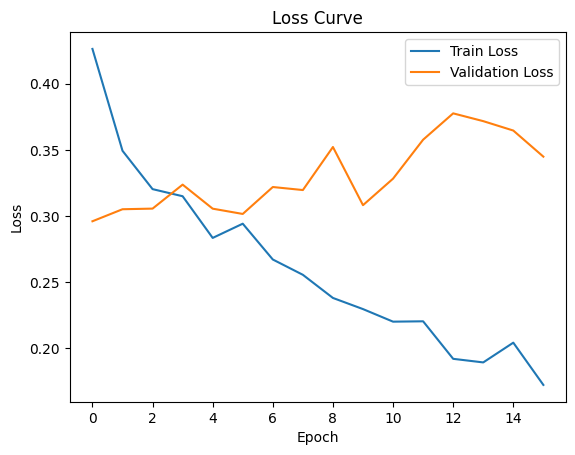

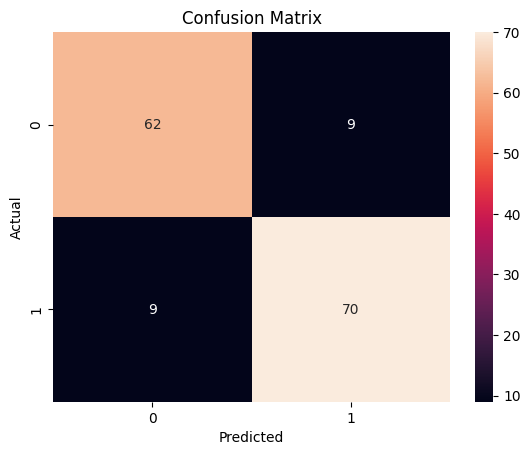

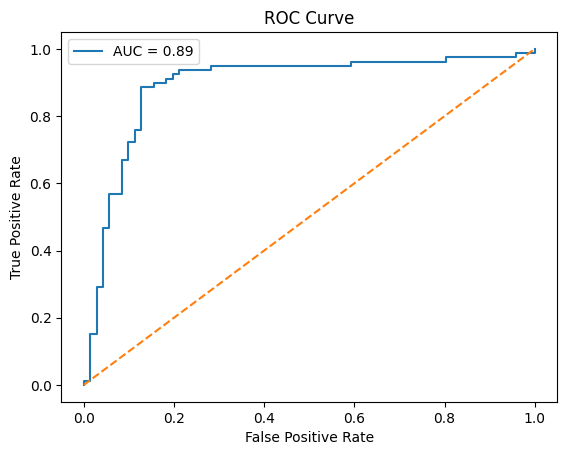

In [63]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "results_0"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:

# X = encode_df[selected_rsfs].values
# y =  y.values

# X = encode_df[selected_rsfs].to_numpy()
# y =  y.to_numpy()

# =========================
# 3. Train / Val / Test Split
# =========================
 
X_train, X_test , y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)
 

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
# ========================================================
# 13. Visualization: Train vs Test Accuracy (CVD Data)
# ========================================================

plt.figure(figsize=(10, 6))

# Plotting the lists collected during the training loop
plt.plot(train_acc_list, label='train')
plt.plot(val_acc_list, label='test') # Using val_acc_list as the 'test' proxy during training

# Labeling according to your provided chart style
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('HGRDIN Model: Train vs Test Accuracy on CVD Data')
plt.legend(loc='upper left')

# Optional: Match the y-axis starting point of your image (0.45 or 0.5)
# plt.ylim(bottom=0.45, top=1.0) 

plt.savefig(os.path.join(results_dir, "hgrdin_accuracy_comparison.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

In [53]:

# =========================
# 5. Training Function
# =========================
def train_model(X_train_np, y_train_np, X_val_np, y_val_np,
                input_size, epochs=100, patience=15,
                batch_size=16, lr=0.001):
    """Train HGRDIN and return best model + history."""
 
    # Scale
    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(X_train_np)
    X_vl    = scaler.transform(X_val_np)
 
    # Tensors
    Xtr = torch.tensor(X_tr, dtype=torch.float32)
    Xvl = torch.tensor(X_vl, dtype=torch.float32)
    ytr = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
    yvl = torch.tensor(y_val_np,   dtype=torch.float32).view(-1, 1)
 
    loader = DataLoader(TensorDataset(Xtr, ytr),
                        batch_size=batch_size, shuffle=True)
 
    model     = HGRDIN(input_size)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
 
    best_val_loss = float('inf')
    best_state    = model.state_dict()
    counter       = 0
 
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []
 
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            out  = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_loss = epoch_loss / len(loader)
 
        # --- Validate ---
        model.eval()
        with torch.no_grad():
            val_out  = model(Xvl)
            val_loss = criterion(val_out, yvl).item()
 
            tr_probs = torch.sigmoid(model(Xtr))
            tr_preds = (tr_probs > 0.5).float()
            vl_probs = torch.sigmoid(val_out)
            vl_preds = (vl_probs > 0.5).float()
 
            tr_acc = accuracy_score(ytr.numpy(), tr_preds.numpy())
            vl_acc = accuracy_score(yvl.numpy(), vl_preds.numpy())
 
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(tr_acc)
        val_acc_hist.append(vl_acc)
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            counter       = 0
        else:
            counter += 1
        if counter >= patience:
            print(f"    Early stopping at epoch {epoch + 1}")
            break
 
    model.load_state_dict(best_state)
    return model, scaler, {
        "train_loss": train_loss_hist,
        "val_loss":   val_loss_hist,
        "train_acc":  train_acc_hist,
        "val_acc":    val_acc_hist,
    }
 
 
# =========================
# 6. Evaluation Function
# =========================
def evaluate_model(model, scaler, X_test_np, y_test_np):
    """Return full metrics dict for a test set."""
    X_sc = scaler.transform(X_test_np)
    Xts  = torch.tensor(X_sc, dtype=torch.float32)
    yts  = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)
 
    model.eval()
    with torch.no_grad():
        logits = model(Xts)
        probs  = torch.sigmoid(logits)
 
    # Threshold tuning on the test set
    best_acc, best_thresh = 0, 0.5
    for t in np.arange(0.3, 0.8, 0.05):
        preds = (probs > t).float()
        acc   = accuracy_score(yts.numpy(), preds.numpy())
        if acc > best_acc:
            best_acc, best_thresh = acc, t
 
    preds = (probs > best_thresh).float()
    cm    = confusion_matrix(yts.numpy(), preds.numpy())
    tn, fp, fn, tp = cm.ravel()
 
    return {
        "accuracy":  accuracy_score(yts.numpy(), preds.numpy()),
        "precision": precision_score(yts.numpy(), preds.numpy(), zero_division=0),
        "recall":    recall_score(yts.numpy(), preds.numpy(), zero_division=0),
        "f1":        f1_score(yts.numpy(), preds.numpy(), zero_division=0),
        "roc_auc":   roc_auc_score(yts.numpy(), probs.numpy()),
        "tpr":       tp / (tp + fn) if (tp + fn) > 0 else 0,
        "fpr":       fp / (fp + tn) if (fp + tn) > 0 else 0,
        "threshold": best_thresh,
        "cm":        cm,
        "probs":     probs.numpy(),
        "y_true":    yts.numpy(),
    }
 
 
# =========================
# 7. Run All Splits
# =========================
SPLITS = [
    (0.70, 0.30),   # 70 / 30
    (0.60, 0.40),   # 60 / 40
    (0.80, 0.20),   # 80 / 20
    (0.50, 0.50),   # 50 / 50
    (0.65, 0.35),   # 65 / 35
]
 
all_results  = {}   # metrics per split
all_history  = {}   # loss/acc curves per split
 
for train_ratio, test_ratio in SPLITS:
    label = f"{int(train_ratio*100)}/{int(test_ratio*100)}"
    print(f"\n{'='*50}")
    print(f"  Split: {label}")
    print(f"{'='*50}")
 
    # ---- Split ----
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42
    )
    # Use 15 % of train as validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.15, random_state=42
    )
 
    print(f"  Train: {len(X_tr):4d}  Val: {len(X_val):4d}  Test: {len(X_test):4d}")
 
    # ---- Train ----
    model, scaler, history = train_model(
        X_tr, y_tr, X_val, y_val,
        input_size=X.shape[1]
    )
 
    # ---- Evaluate ----
    metrics = evaluate_model(model, scaler, X_test, y_test)
    all_results[label] = metrics
    all_history[label] = history
 
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall   : {metrics['recall']:.4f}")
    print(f"  F1-Score : {metrics['f1']:.4f}")
    print(f"  ROC-AUC  : {metrics['roc_auc']:.4f}")
    print(f"  Threshold: {metrics['threshold']:.2f}")
 
 
# =========================
# 8. Summary Table
# =========================
summary_rows = []
for label, m in all_results.items():
    summary_rows.append({
        "Split":     label,
        "Accuracy":  round(m["accuracy"],  4),
        "Precision": round(m["precision"], 4),
        "Recall":    round(m["recall"],    4),
        "F1-Score":  round(m["f1"],        4),
        "ROC-AUC":   round(m["roc_auc"],   4),
        "TPR":       round(m["tpr"],       4),
        "FPR":       round(m["fpr"],       4),
        "Threshold": round(m["threshold"], 2),
    })
 


  Split: 70/30
  Train:  595  Val:  105  Test:  300
    Early stopping at epoch 19
  Accuracy : 0.9133
  Precision: 0.9231
  Recall   : 0.9114
  F1-Score : 0.9172
  ROC-AUC  : 0.9114
  Threshold: 0.45

  Split: 60/40
  Train:  510  Val:   90  Test:  400
    Early stopping at epoch 28
  Accuracy : 0.9100
  Precision: 0.9087
  Recall   : 0.9175
  F1-Score : 0.9130
  ROC-AUC  : 0.9212
  Threshold: 0.45

  Split: 80/20
  Train:  680  Val:  120  Test:  200
    Early stopping at epoch 21
  Accuracy : 0.9050
  Precision: 0.9126
  Recall   : 0.9038
  F1-Score : 0.9082
  ROC-AUC  : 0.8915
  Threshold: 0.45

  Split: 50/50
  Train:  425  Val:   75  Test:  500
    Early stopping at epoch 25
  Accuracy : 0.9060
  Precision: 0.9127
  Recall   : 0.9020
  F1-Score : 0.9073
  ROC-AUC  : 0.9039
  Threshold: 0.40

  Split: 65/35
  Train:  552  Val:   98  Test:  350
    Early stopping at epoch 17
  Accuracy : 0.9143
  Precision: 0.9176
  Recall   : 0.9176
  F1-Score : 0.9176
  ROC-AUC  : 0.8973
  Thresh

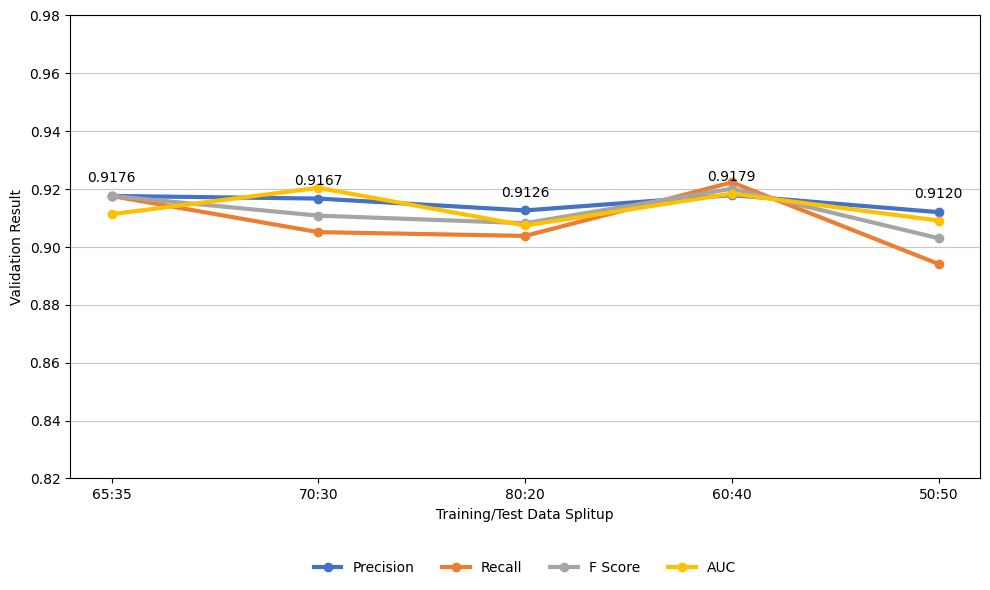

In [54]:
import matplotlib.pyplot as plt

# Data from your provided results
splits = ['65:35', '70:30', '80:20', '60:40', '50:50']
precision = [0.9176, 0.9167, 0.9126, 0.9179, 0.9120]
recall = [0.9176, 0.9051, 0.9038, 0.9223, 0.8941]
f1_score = [0.9176, 0.9108, 0.9082, 0.9201, 0.9030]
auc = [0.9113, 0.9204, 0.9074, 0.9184, 0.9091]

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(splits, precision, marker='o', label='Precision', color='#4472C4', linewidth=3)
plt.plot(splits, recall, marker='o', label='Recall', color='#ED7D31', linewidth=3)
plt.plot(splits, f1_score, marker='o', label='F Score', color='#A5A5A5', linewidth=3)
plt.plot(splits, auc, marker='o', label='AUC', color='#FFC000', linewidth=3)

# Formatting to match "Screenshot 2026-05-06 182559.png"
plt.ylabel('Validation Result')
plt.xlabel('Training/Test Data Splitup')
plt.ylim(0.82, 0.98)
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

# Add data labels for clarity
for i, txt in enumerate(precision):
    plt.annotate(f"{txt:.4f}", (splits[i], precision[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "spliting.png"), dpi=300)
plt.show()

In [59]:
import numpy as np
import pandas as pd
import time  # Added for timing
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN (With Timing)
    # =========================
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()
    train_duration = end_train - start_train

    # =========================
    # PREDICT (With Timing)
    # =========================
    start_test = time.perf_counter()
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    end_test = time.perf_counter()
    test_duration = end_test - start_test

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr_list, tpr_list, _ = roc_curve(y_test, y_pred_prob)

    # Store results including time
    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "Train Time": round(train_duration, 4),
        "Test Time": round(test_duration, 4),
        "fpr": fpr_list,
        "tpr": tpr_list
    }

    tn, fp, fn, tp = cm.ravel()
    tpr_val = tp / (tp + fn)
    fpr_val = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr_val:.4f}")
    print(f"False Positive Rate (FPR): {fpr_val:.4f}")

    # Print Time Results
    print(f"Training Time : {train_duration:.4f} sec")
    print(f"Testing Time  : {test_duration:.4f} sec")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name

# =========================
# AFTER LOOP: Summary Table
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)

# Optional: Display time comparison table
time_df = pd.DataFrame.from_dict(results, orient='index')[['Train Time', 'Test Time', 'AUC']]
print("\nModel Time Comparison:")
print(time_df)


──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


True Positive Rate (TPR):  0.9114
False Positive Rate (FPR): 0.1127
Training Time : 0.2428 sec
Testing Time  : 0.0131 sec

Accuracy  : 0.9000
Precision : 0.9000
Recall    : 0.9114
F1-Score  : 0.9057
ROC-AUC   : 0.8870

Confusion Matrix:
[[63  8]
 [ 7 72]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.89        71
         1.0       0.90      0.91      0.91        79

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7722
False Positive Rate (FPR): 0.2254
Training Time : 0.0308 sec
Testing Time  : 0.0019 sec

Accuracy  : 0.7733
Precision : 0.7922
Recall    : 0.7722
F1-Score  : 0.7821
ROC-AUC   : 0.7734

Confusion Matrix:
[[55 16]
 [18 61]]

Classification Report:


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


True Positive Rate (TPR):  0.9241
False Positive Rate (FPR): 0.1127
Training Time : 0.1322 sec
Testing Time  : 0.0160 sec

Accuracy  : 0.9067
Precision : 0.9012
Recall    : 0.9241
F1-Score  : 0.9125
ROC-AUC   : 0.8884

Confusion Matrix:
[[63  8]
 [ 6 73]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90        71
         1.0       0.90      0.92      0.91        79

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150


──────────────────────────────────────────────────
Model: Random Forest
──────────────────────────────────────────────────


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


True Positive Rate (TPR):  0.8987
False Positive Rate (FPR): 0.1127
Training Time : 0.4735 sec
Testing Time  : 0.0361 sec

Accuracy  : 0.8933
Precision : 0.8987
Recall    : 0.8987
F1-Score  : 0.8987
ROC-AUC   : 0.8863

Confusion Matrix:
[[63  8]
 [ 8 71]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89        71
         1.0       0.90      0.90      0.90        79

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150


──────────────────────────────────────────────────
Model: KNN
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9114
False Positive Rate (FPR): 0.1127
Training Time : 0.0427 sec
Testing Time  : 0.0939 sec

Accuracy  : 0.9000
Precision : 0.9000
Recall    : 0.9114
F1-Score  : 0.9057
ROC-AUC   : 0.9140

Confusion Matrix:
[[63  8]
 [ 7 72]]

Classification Report:

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.1268
Training Time : 0.3152 sec
Testing Time  : 0.0108 sec

Accuracy  : 0.8800
Precision : 0.8861
Recall    : 0.8861
F1-Score  : 0.8861
ROC-AUC   : 0.8998

Confusion Matrix:
[[62  9]
 [ 9 70]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87        71
         1.0       0.89      0.89      0.89        79

    accuracy                           0.88       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150


🏆 BEST MODEL: KNN
AUC Score   : 0.9140

Model Time Comparison:
                     Train Time  Test Time     AUC
Logistic Regression      0.2428     0.0131  0.8870
dt                       0.0308     0.0019  0.7734
gnb                      0.0252     0.0095  0.8978
SVM                      0.1322     0.0160  0.8884
Random Forest            0.4735     0.0361  0.8863
KNN                    

                        time
Logistic Regression      0.2428     
dt                       0.0308     
gnb                      0.0252     
SVM                      0.1322     
Random Forest            0.4735     
KNN                      0.0427     
XGBoost                  0.3152